In [1]:
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
import random

In [6]:
load_dotenv()
your_llm = ChatOpenAI(model="gpt-4o-mini")
# your_llm = ChatOllama(model = 'llama3.1:latest')

In [7]:
def random_number(x: int) -> int:
    """
    Generate a random number between 1 and x
    """
    return random.randint(1, x)

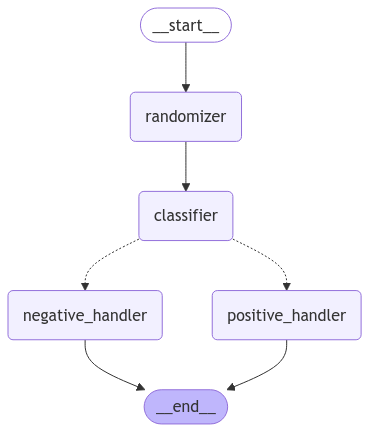

In [ ]:
from agentic_framework.nodes import AgentNode, DecisionNode, InputNode
from agentic_framework.graph import AgenticGraph
from agentic_framework.state import AgenticState

# Create nodes
input_node = InputNode(
    name="input",
    node_prompt="Provide an input",
    n = 0
)

agent = AgentNode(
    name="randomizer",
    llm=your_llm,  # Your language model instance
    node_prompt="get random number based on user input",
)
agent.bind_tools([random_number])

decision = DecisionNode(
    name="classifier",
    llm=your_llm,
    node_prompt="if number is more than 5, say positive, else say negative",
    choices=["positive", "negative"]
)

positive_handler = AgentNode(
    name="positive_handler",
    llm=your_llm,
    node_prompt="report number in happy tone"
)

negative_handler = AgentNode(
    name="negative_handler",
    llm=your_llm,
    node_prompt="report number in sad tone"
)

# Connect nodes
agent > decision
decision["positive"] > positive_handler
decision["negative"] > negative_handler

# Create and build graph
graph_0 = AgenticGraph(
    state=AgenticState,
    start_node=agent,
    end_nodes={negative_handler, positive_handler}
)

graph_0

In [10]:
graph_0.invoke({'messages': ['Hi, random up to 65'], 'log': []})

[SystemMessage(content='if number is more than 5, say positive, else say negative', additional_kwargs={}, response_metadata={}), 'Hi, random up to 65', AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_U5PzgEm33fYzfOu1PXWT7lqd', 'function': {'arguments': '{"x":65}', 'name': 'random_number'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 62, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_bd83329f63', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-975d7ae9-cf5c-49be-a545-51c05383b7ac-0', tool_calls=[{'name': 'random_number', 'args': {'x': 65}, 'id': 'call_U5PzgEm33fYzfOu1PXWT7lqd', 'type': 'tool_call'}], usage_metadata={'input_tokens': 62, 'output_

{'messages': ['Hi, random up to 65',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_U5PzgEm33fYzfOu1PXWT7lqd', 'function': {'arguments': '{"x":65}', 'name': 'random_number'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 62, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_bd83329f63', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-975d7ae9-cf5c-49be-a545-51c05383b7ac-0', tool_calls=[{'name': 'random_number', 'args': {'x': 65}, 'id': 'call_U5PzgEm33fYzfOu1PXWT7lqd', 'type': 'tool_call'}], usage_metadata={'input_tokens': 62, 'output_tokens': 15, 'total_tokens': 77, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'

In [6]:
# agent_1 = AgentNode(name="agent_1", llm=your_llm, node_prompt="แต่งกลอน 1 วรรค")
# agent_2 = AgentNode(name="agent_2", llm=your_llm, node_prompt="แต่งกลอนเพิ่มอีก 1 วรรค")
# agent_3 = AgentNode(name="agent_3", llm=your_llm, node_prompt="แต่งกลอนเพิ่มอีก 1 วรรค")
# agent_4 = AgentNode(name="agent_4", llm=your_llm, node_prompt="รวมกลอนทั้งหมดเข้าด้วยกัน")

# agent_1 > agent_2
# agent_3 > agent_4

# graph_0 = AgenticGraph(
#     name = "graph_0",
#     state=AgenticState,
#     start_node=agent_1,
#     end_nodes=agent_2
# )

# graph_1 = AgenticGraph(
#     name = "graph_1",
#     state=AgenticState,
#     start_node=agent_3,
#     end_nodes=agent_4
# )

# graph_0 > graph_1
# graph_big = AgenticGraph(
#     name = "graph_big",
#     state=AgenticState,
#     start_node=graph_0,
#     end_nodes=graph_1
# )

# graph_big


In [7]:
# from langchain_core.messages import HumanMessage
# state_output = graph_big.invoke({
#     "messages": [HumanMessage(content="การเมืองไทย")], 
#     'log': []
#     })
# state_output['log']